In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)

from sklearn.dummy import DummyClassifier


from scipy.stats import wilcoxon

In [29]:
df = pd.read_csv("bank-full.csv", sep=";")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [30]:
df.shape

(45211, 17)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [32]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [33]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
df["y"].value_counts()

,count
y,
no,39922
yes,5289


In [36]:
df["y"].value_counts(normalize=True) * 100

,proportion
y,
no,88.30152
yes,11.69848


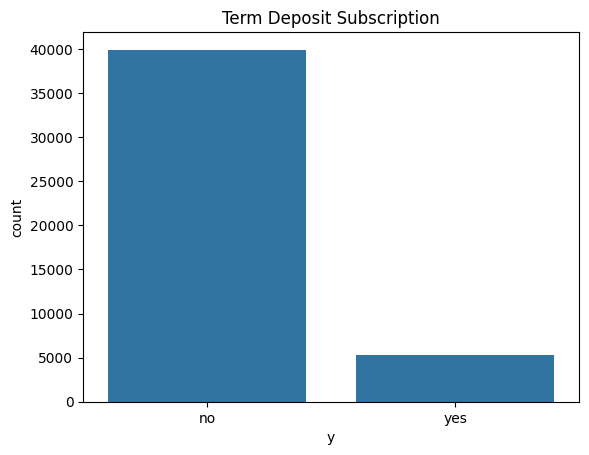

In [37]:
sns.countplot(data=df, x="y")
plt.title("Term Deposit Subscription")
plt.savefig("figures/target_distribution.png", bbox_inches="tight")
plt.show()

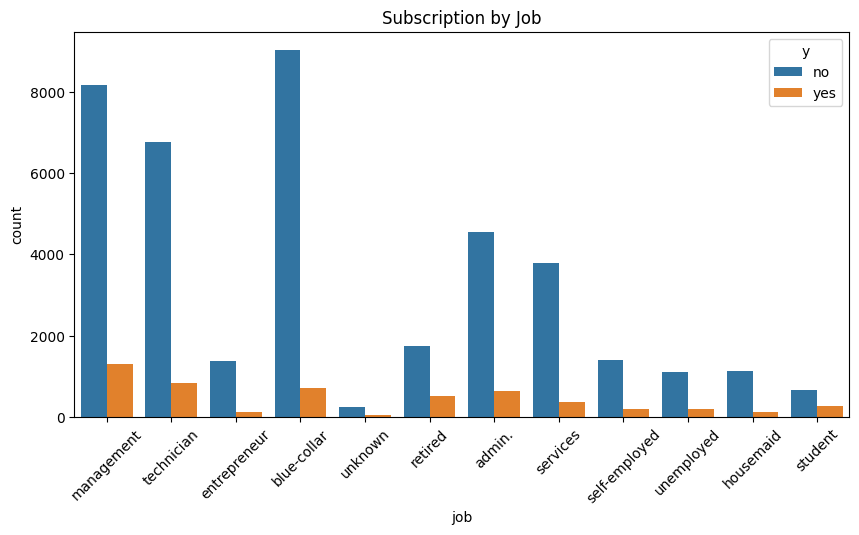

In [38]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="job", hue="y")
plt.xticks(rotation=45)
plt.title("Subscription by Job")
plt.savefig("figures/subscription_by_job.png", bbox_inches="tight")
plt.show()

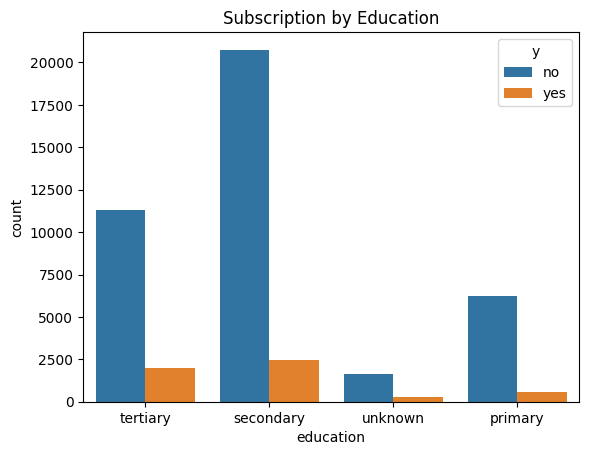

In [39]:
sns.countplot(data=df, x="education", hue="y")
plt.title("Subscription by Education")
plt.savefig("figures/subscription_by_education.png", bbox_inches="tight")
plt.show()

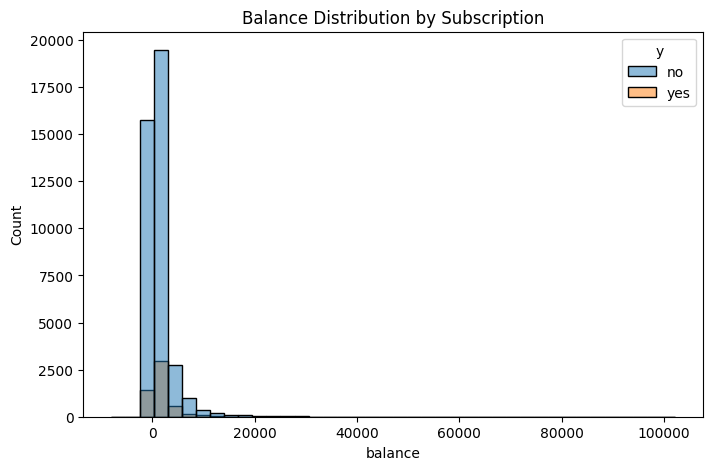

In [40]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="balance", hue="y", bins=40)
plt.title("Balance Distribution by Subscription")
plt.savefig("figures/balance_distribution.png", bbox_inches="tight")
plt.show()

In [41]:
X = df.drop("y", axis=1)
y = df["y"].map({"no": 0, "yes": 1})

In [42]:
y.value_counts()

,count
y,
0,39922
1,5289


In [43]:
categorical_cols = X.select_dtypes(include="object").columns
numeric_cols = X.select_dtypes(exclude="object").columns

print("Categorical:", list(categorical_cols))
print("Numerical:", list(numeric_cols))

Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numerical: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [44]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [45]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),

    "SVM": SVC(
        kernel="linear",
        probability=True,
        class_weight="balanced",
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

In [46]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [47]:
from sklearn.model_selection import train_test_split

X = df.drop("y", axis=1)
y = df["y"].map({"no": 0, "yes": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
results = []

for name, model in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=3,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

results_df = pd.DataFrame(results)

results_df.sort_values("ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,Random Forest,0.901543,0.676547,0.303943,0.419209,0.927118
5,Gradient Boosting,0.905994,0.658035,0.408647,0.504159,0.925053
3,SVM,0.836541,0.404044,0.836206,0.544807,0.910186
0,Logistic Regression,0.843923,0.415228,0.818243,0.550875,0.909821
4,KNN,0.893801,0.581948,0.327342,0.418920,0.829752
1,Decision Tree,0.875636,0.467210,0.444575,0.455500,0.688659


In [48]:
from sklearn.model_selection import train_test_split

X = df.drop("y", axis=1)
y = df["y"].map({"no": 0, "yes": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

<Figure size 1000x600 with 0 Axes>

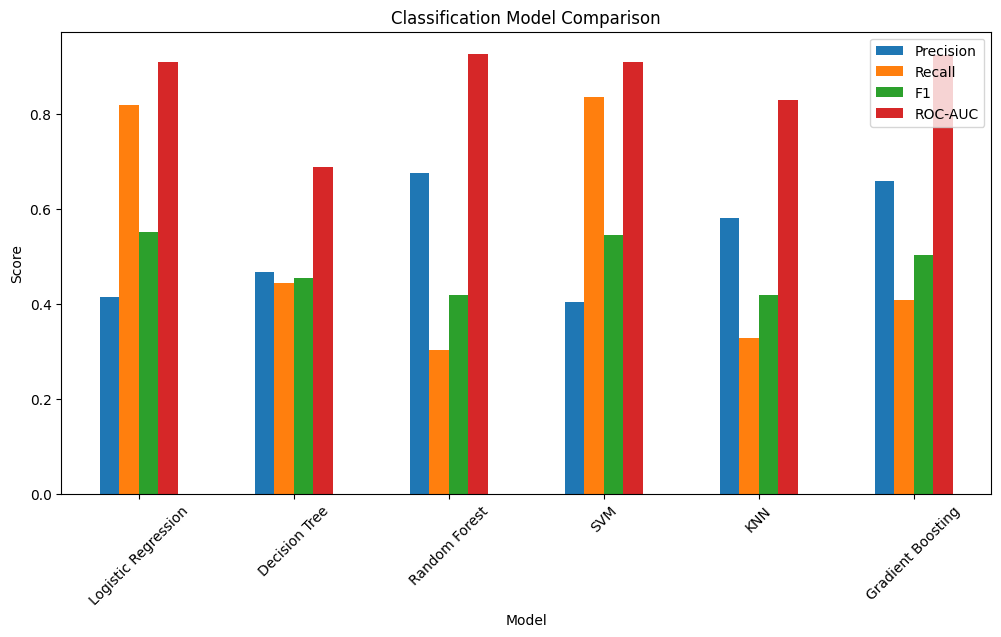

In [49]:
plt.figure(figsize=(10,6))

results_df.set_index("Model")[
    ["Precision", "Recall", "F1", "ROC-AUC"]
].plot(kind="bar", figsize=(12,6))

plt.title("Classification Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.savefig("figures/model_comparison.png", bbox_inches="tight")
plt.show()

In [74]:
baseline = DummyClassifier(strategy="most_frequent")

baseline_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", baseline)
])

baseline_pipe.fit(X_train, y_train)

baseline_pred = baseline_pipe.predict(X_test)

print(classification_report(y_test, baseline_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94      7985
           1       0.00      0.00      0.00      1058

    accuracy                           0.88      9043
   macro avg       0.44      0.50      0.47      9043
weighted avg       0.78      0.88      0.83      9043



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [51]:
best_model_name = results_df.loc[
    results_df["ROC-AUC"].idxmax(), "Model"
]

best_model_name

'Random Forest'

In [76]:
#Evaluate best model
best_model = models[best_model_name]

best_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])

best_pipe.fit(X_train, y_train)

y_pred = best_pipe.predict(X_test)

In [77]:
#classification_report
print(classification_report(
    y_test,
    y_pred,
    target_names=["No", "Yes"]
))

              precision    recall  f1-score   support

          No       0.92      0.98      0.95      7985
         Yes       0.68      0.33      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.80      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



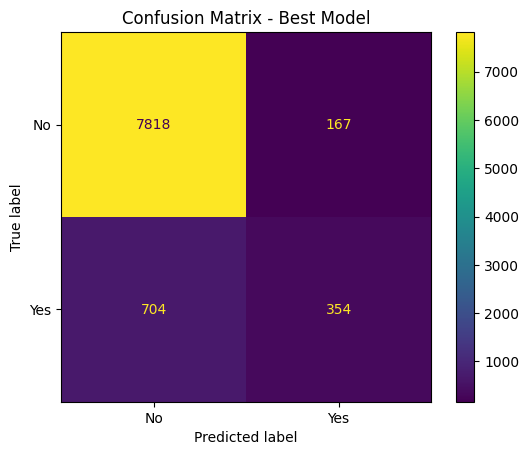

In [75]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot()
plt.title("Confusion Matrix - Best Model")
plt.savefig("figures/confusion_matrix.png", bbox_inches="tight")
plt.show()

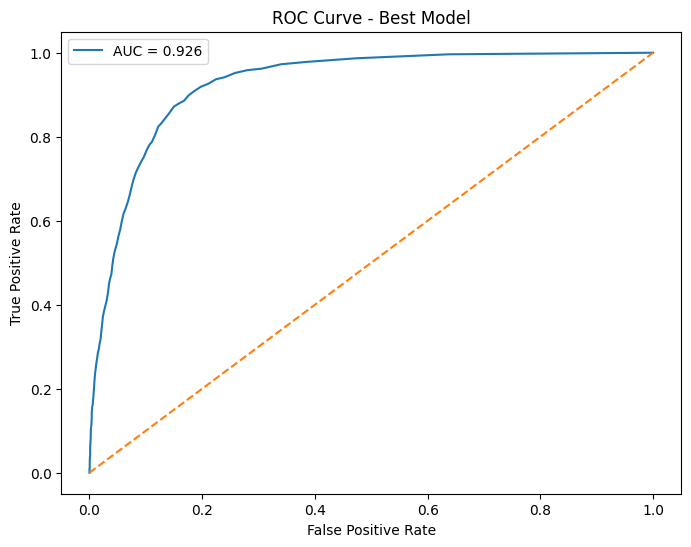

In [73]:
#compare the ROC curve of our best model
y_prob = best_pipe.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best Model")
plt.legend()
plt.savefig("figures/roc_curve.png", bbox_inches="tight")
plt.show()

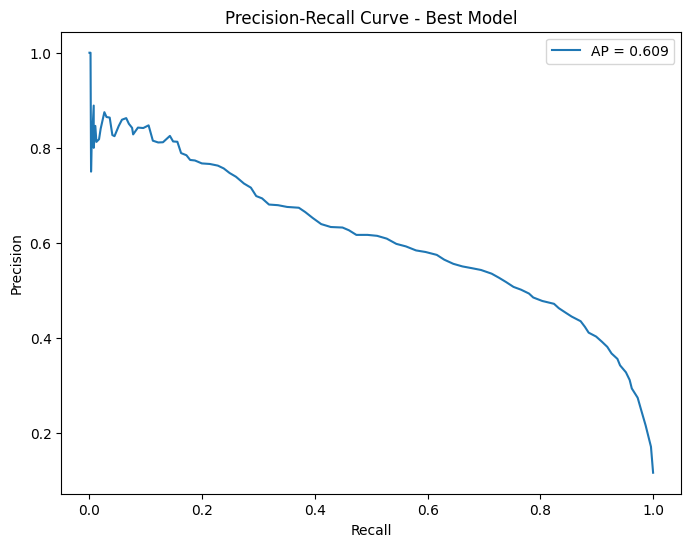

In [72]:
#Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

ap_score = average_precision_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"AP = {ap_score:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Best Model")
plt.legend()
plt.savefig("figures/precision_recall_curve.png", bbox_inches="tight")
plt.show()

In [78]:
#test different thresholds and find one that gives a better F1-score.
thresholds_to_test = np.arange(0.1, 0.91, 0.05)

f1_scores = []

for threshold in thresholds_to_test:
    y_pred_threshold = (y_prob >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred_threshold)
    f1_scores.append(f1)

best_index = np.argmax(f1_scores)
best_threshold = thresholds_to_test[best_index]
best_f1 = f1_scores[best_index]

print("Best Threshold:", best_threshold)
print("Best F1 Score:", best_f1)

Best Threshold: 0.25000000000000006
Best F1 Score: 0.6090342679127726


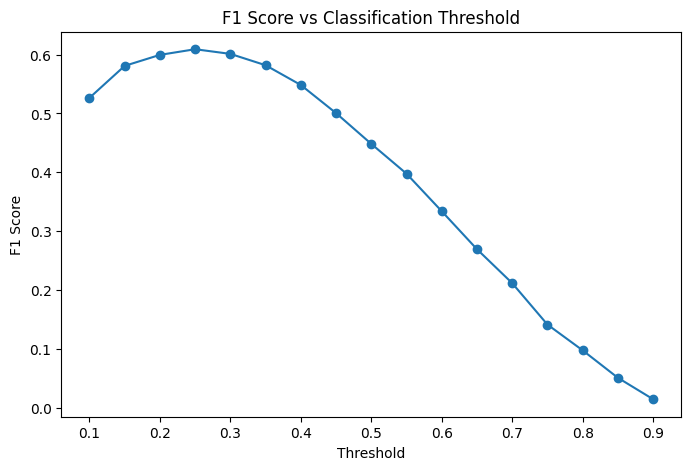

In [71]:
#visually see which threshold gives the highest F1
plt.figure(figsize=(8, 5))
plt.plot(thresholds_to_test, f1_scores, marker="o")

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Classification Threshold")
plt.savefig("figures/threshold_f1.png", bbox_inches="tight")
plt.show()

In [70]:
#runs 3 folds cross validation for each model
cv_scores = {}

for name, model in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    cv_scores[name] = scores["test_score"]

cv_scores

{'Logistic Regression': array([0.55542255, 0.55042816, 0.54222853]),
 'Decision Tree': array([0.44915874, 0.44153958, 0.45123726]),
 'Random Forest': array([0.40818315, 0.43285024, 0.43309002]),
 'SVM': array([0.55167565, 0.54195323, 0.53918639]),
 'KNN': array([0.41704442, 0.42738205, 0.44824482]),
 'Gradient Boosting': array([0.5085034 , 0.51672535, 0.52399824])}

In [69]:
#compare best model with the second best model
sorted_models = results_df.sort_values(
    "F1",
    ascending=False
)["Model"].tolist()

best_name = sorted_models[0]
second_name = sorted_models[1]

stat, p_value = wilcoxon(
    cv_scores[best_name],
    cv_scores[second_name]
)

print("Best Model:", best_name)
print("Second Model:", second_name)
print("p-value:", p_value)

Best Model: Logistic Regression
Second Model: SVM
p-value: 0.25


In [67]:
#sort all models from best to worst  according to ROC-AOC
final_results = results_df.sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

final_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.901543,0.676547,0.303943,0.419209,0.927118
1,Gradient Boosting,0.905994,0.658035,0.408647,0.504159,0.925053
2,SVM,0.836541,0.404044,0.836206,0.544807,0.910186
3,Logistic Regression,0.843923,0.415228,0.818243,0.550875,0.909821
4,KNN,0.893801,0.581948,0.327342,0.418920,0.829752
5,Decision Tree,0.875636,0.467210,0.444575,0.455500,0.688659


In [68]:
#display best model
best_model = final_results.iloc[0]

print("Best Model:", best_model["Model"])
print("Accuracy:", round(best_model["Accuracy"], 3))
print("Precision:", round(best_model["Precision"], 3))
print("Recall:", round(best_model["Recall"], 3))
print("F1 Score:", round(best_model["F1"], 3))
print("ROC-AUC:", round(best_model["ROC-AUC"], 3))

Best Model: Random Forest
Accuracy: 0.902
Precision: 0.677
Recall: 0.304
F1 Score: 0.419
ROC-AUC: 0.927
